In [20]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [21]:
df = pd.read_csv("substancias_remineralizadoras.csv")

print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (109, 57)


,Autor,Ano,Substancia 1,Substancia 2,Substancia 3,Substância 4,Substancia 5,Concentração substancia 1,Concentração substancia 2,Concentração substancia 3,...,Area_de_superficie_polar,Teste_microdureza,Tempo Teste EDX (dias),Teste_EDX,Tempo microscopia (dias),Microscopia_eletrônica (micrometros) µm²,Microscopia_eletrônica (classificação),Mineraliza ou não,Doi,Justificativa
0,"Goldberg, Michel et al.",2011,colageno_tipo_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,https://pmc.ncbi.nlm.nih.gov/articles/PMC3360947/,NaN
1,"Goldberg, Michel et al.",2011,colageno_tipo_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
2,"Goldberg, Michel et al.",2011,hidroxiapatita,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,556.5,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
3,"Goldberg, Michel et al.",2011,glicoproteina_Da_dentina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
4,"Goldberg, Michel et al.",2011,sialoproteina_ossea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


In [22]:
target = "Mineraliza ou não"

print(df[target].value_counts())
print(df[target].value_counts(normalize=True))

Mineraliza ou não
1    72
0    37
Name: count, dtype: int64
Mineraliza ou não
1    0.66055
0    0.33945
Name: proportion, dtype: float64


In [23]:
target = "Mineraliza ou não"

colunas_remover = [
    target,
    "Autor",
    "Ano",
    "Doi",
    "Justificativa",

    # Colunas ligadas a resultados experimentais
    "Teste_microdureza",
    "Tempo Teste EDX (dias)",
    "Teste_EDX",
    "Tempo microscopia (dias)",
    "Microscopia_eletrônica (micrometros) µm²",
    "Microscopia_eletrônica (classificação)"
]

colunas_existentes_para_remover = [
    col for col in colunas_remover if col in df.columns
]

X = df.drop(columns=colunas_existentes_para_remover)
y = df[target].astype(int)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (109, 46)
Formato de y: (109,)


In [24]:
colunas_numericas = X.select_dtypes(include=["number"]).columns.tolist()

colunas_categoricas = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Quantidade de colunas numéricas:", len(colunas_numericas))
print("Quantidade de colunas categóricas:", len(colunas_categoricas))

print("\nColunas numéricas:")
print(colunas_numericas)

print("\nColunas categóricas:")
print(colunas_categoricas)

Quantidade de colunas numéricas: 8
Quantidade de colunas categóricas: 38

Colunas numéricas:
['Concentração g substancia 1', 'Frequencia de aplicação/dia', 'Tempo de aplicação (min)', 'Numero de aminoacidos', 'pH', 'Aceptores_de_ligacoes_de_hidrogenio', 'Doadores_de_ligacoes_de_hidrogenio', 'Area_de_superficie_polar']

Colunas categóricas:
['Substancia 1', 'Substancia 2', 'Substancia 3', 'Substância 4', 'Substancia 5', 'Concentração substancia 1', 'Concentração substancia 2', 'Concentração substancia 3', 'Concentração substancia 4', 'Concentração substancia 5', 'Porcentagem substancia 1', 'Porcentagem substancia 2', 'Concentração Composição 1', 'Composição 1', 'Concentração Composição 2', 'Composição 2', 'Concentração Composição 3', 'Composição 3', 'Concentração comp 4', 'Composição 4', 'Concentração comp 5', 'Composição 5', 'Concentração comp 6', 'Composição 6', 'Composição 7', 'Composição 8', 'Composição 9', 'Composição 10', 'Composição 11', 'Composição 12', 'Composição 13', 'Composi

In [25]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessamento = ColumnTransformer(
    transformers=[
        ("numericas", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas),

        ("categoricas", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Não informado")),
            ("onehot", onehot)
        ]), colunas_categoricas)
    ]
)

In [26]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
modelos = {
    "Dummy": DummyClassifier(strategy="most_frequent"),

    "Regressão Logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42
    ),

    "Árvore de Decisão": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "XGBoost": XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)
}

In [28]:
metricas = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [29]:
resultados = []

for nome_modelo, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessamento", preprocessamento),
        ("modelo", modelo)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=metricas,
        n_jobs=-1
    )

    linha = {
        "modelo": nome_modelo,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    }

    resultados.append(linha)

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by=["balanced_accuracy", "recall", "f1"],
    ascending=False
)

df_resultados

,modelo,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
3,Árvore de Decisão,0.705628,0.702500,0.826923,0.708571,0.762610,0.702500
1,Regressão Logística,0.715584,0.694048,0.804510,0.766667,0.777942,0.734949
2,SVM,0.604329,0.671429,0.905051,0.471429,0.599716,0.738138
4,Random Forest,0.687446,0.628810,0.741548,0.821905,0.774122,0.805782
5,Gradient Boosting,0.687446,0.628690,0.746201,0.818095,0.771848,0.787389
6,XGBoost,0.632900,0.553810,0.698619,0.807619,0.742258,0.726003
0,Dummy,0.660606,0.500000,0.660606,1.000000,0.795435,0.500000


In [30]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

resultados_confusao = []

for nome_modelo, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessamento", preprocessamento),
        ("modelo", modelo)
    ])

    y_pred = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv,
        n_jobs=-1
    )

    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    resultados_confusao.append({
        "modelo": nome_modelo,
        "VN": tn,
        "FP": fp,
        "FN": fn,
        "VP": tp,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0)
    })

df_confusao = pd.DataFrame(resultados_confusao)

df_confusao = df_confusao.sort_values(
    by=["FN", "balanced_accuracy", "f1"],
    ascending=[True, False, False]
)

df_confusao

,modelo,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,Dummy,0,37,0,72,0.660550,0.500000,0.660550,1.000000,0.795580
4,Random Forest,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
5,Gradient Boosting,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
6,XGBoost,11,26,14,58,0.633028,0.551426,0.690476,0.805556,0.743590
1,Regressão Logística,23,14,17,55,0.715596,0.692755,0.797101,0.763889,0.780142
3,Árvore de Decisão,26,11,21,51,0.706422,0.705518,0.822581,0.708333,0.761194
2,SVM,32,5,38,34,0.605505,0.668544,0.871795,0.472222,0.612613


# Treinamento Novo
Aqui eu fiz um novo levantamento ou "Benchmark" o testar novos algoritmos para então realmente ver se o Random Forest é o melhor.


In [31]:
from sklearn.decomposition import PCA
from sklearn.base import clone


In [32]:
modelos_finalistas = {
    "Regressão Logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),


    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )
}

In [33]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

def avaliar_modelo(nome_modelo, modelo, usar_pca=False):
    
    etapas = [
        ("preprocessamento", preprocessamento)
    ]

    if usar_pca:
        etapas.append(("scaler_pos_preprocessamento", StandardScaler()))
        etapas.append(("pca_90", PCA(n_components=0.90, random_state=42)))

    etapas.append(("modelo", clone(modelo)))

    pipeline = Pipeline(steps=etapas)

    y_pred = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv,
        n_jobs=-1
    )

    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    return {
        "modelo": nome_modelo,
        "versao": "Com PCA 90%" if usar_pca else "Sem PCA",
        "VN": tn,
        "FP": fp,
        "FN": fn,
        "VP": tp,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0)
    }

In [34]:
resultados_pca = []

for nome_modelo, modelo in modelos_finalistas.items():
    resultados_pca.append(
        avaliar_modelo(nome_modelo, modelo, usar_pca=False)
    )

    resultados_pca.append(
        avaliar_modelo(nome_modelo, modelo, usar_pca=True)
    )

df_pca = pd.DataFrame(resultados_pca)

df_pca = df_pca.sort_values(
    by=["FN", "balanced_accuracy", "f1"],
    ascending=[True, False, False]
)

df_pca

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
7,XGBoost,Com PCA 90%,12,25,8,64,0.697248,0.606607,0.719101,0.888889,0.795031
5,Gradient Boosting,Com PCA 90%,10,27,10,62,0.660550,0.565691,0.696629,0.861111,0.770186
3,Random Forest,Com PCA 90%,7,30,12,60,0.614679,0.511261,0.666667,0.833333,0.740741
2,Random Forest,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
4,Gradient Boosting,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
6,XGBoost,Sem PCA,11,26,14,58,0.633028,0.551426,0.690476,0.805556,0.743590
0,Regressão Logística,Sem PCA,23,14,17,55,0.715596,0.692755,0.797101,0.763889,0.780142
1,Regressão Logística,Com PCA 90%,20,17,21,51,0.651376,0.624437,0.750000,0.708333,0.728571


In [35]:
df_finalistas = df_pca[
    (
        ((df_pca["modelo"] == "XGBoost") & (df_pca["versao"] == "Com PCA 90%")) |
        ((df_pca["modelo"] == "Gradient Boosting") & (df_pca["versao"] == "Com PCA 90%")) |
        ((df_pca["modelo"] == "Random Forest") & (df_pca["versao"] == "Sem PCA")) |
        ((df_pca["modelo"] == "Gradient Boosting") & (df_pca["versao"] == "Sem PCA")) |
        ((df_pca["modelo"] == "XGBoost") & (df_pca["versao"] == "Sem PCA"))
    )
].copy()

df_finalistas = df_finalistas.sort_values(
    by=["FN", "balanced_accuracy", "f1"],
    ascending=[True, False, False]
)

df_finalistas

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
7,XGBoost,Com PCA 90%,12,25,8,64,0.697248,0.606607,0.719101,0.888889,0.795031
5,Gradient Boosting,Com PCA 90%,10,27,10,62,0.660550,0.565691,0.696629,0.861111,0.770186
2,Random Forest,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
4,Gradient Boosting,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
6,XGBoost,Sem PCA,11,26,14,58,0.633028,0.551426,0.690476,0.805556,0.743590


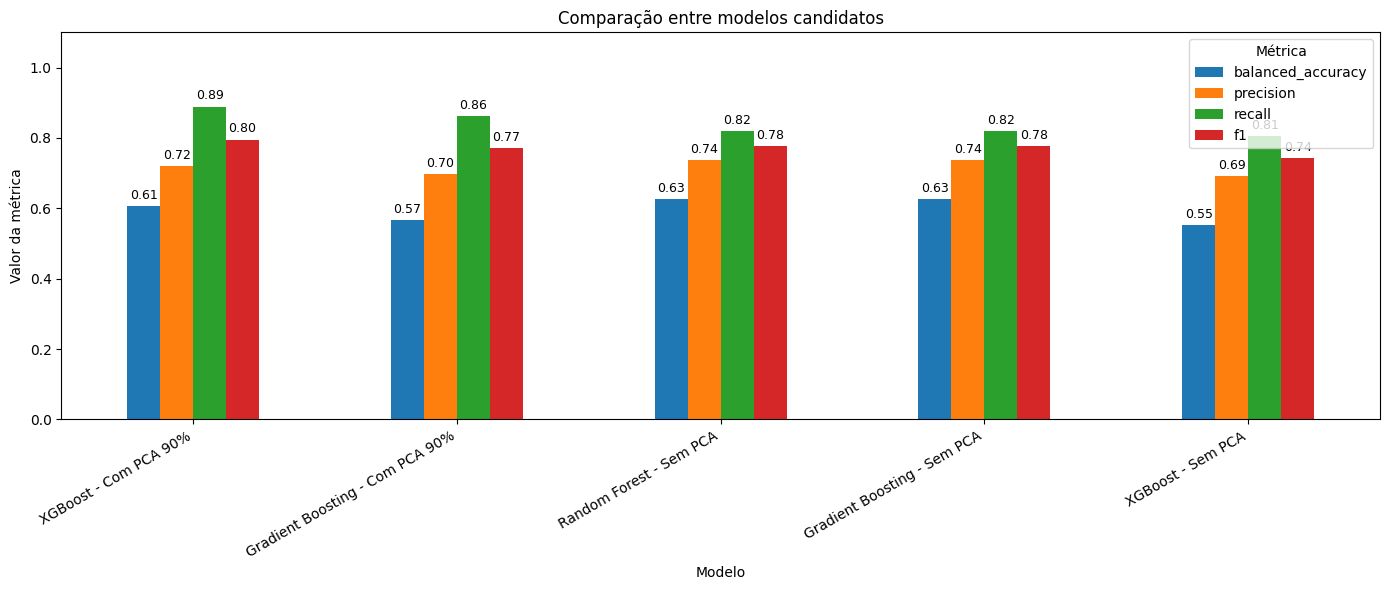

In [36]:
import matplotlib.pyplot as plt

metricas_plot = ["balanced_accuracy", "precision", "recall", "f1"]

df_plot = df_finalistas.copy()
df_plot["modelo_versao"] = df_plot["modelo"] + " - " + df_plot["versao"]

ax = df_plot.set_index("modelo_versao")[metricas_plot].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Comparação entre modelos candidatos")
plt.ylabel("Valor da métrica")
plt.xlabel("Modelo")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.10)
plt.legend(title="Métrica")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Seleção dos modelos candidatos

Após a comparação inicial entre diferentes algoritmos de classificação, foram selecionados os modelos candidatos para a próxima etapa de otimização.

A seleção priorizou o número de falsos negativos e o recall da classe positiva, pois o objetivo do projeto é uma triagem inicial de compostos com potencial de mineralização/remineralização.

Nesta etapa, foram considerados principalmente os algoritmos Random Forest, Gradient Boosting e XGBoost, por estarem alinhados ao escopo metodológico definido para a comparação.

Os modelos candidatos selecionados foram:

- XGBoost com PCA 90%;
- Gradient Boosting com PCA 90%;
- Random Forest sem PCA;
- Gradient Boosting sem PCA.

In [37]:
df_finalistas_passo3 = df_pca[
    (
        ((df_pca["modelo"] == "XGBoost") & (df_pca["versao"] == "Com PCA 90%")) |
        ((df_pca["modelo"] == "Gradient Boosting") & (df_pca["versao"] == "Com PCA 90%")) |
        ((df_pca["modelo"] == "Random Forest") & (df_pca["versao"] == "Sem PCA")) |
        ((df_pca["modelo"] == "Gradient Boosting") & (df_pca["versao"] == "Sem PCA"))
    )
].copy()

df_finalistas_passo3 = df_finalistas_passo3.sort_values(
    by=["FN", "recall", "f1", "balanced_accuracy"],
    ascending=[True, False, False, False]
)

df_finalistas_passo3

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
7,XGBoost,Com PCA 90%,12,25,8,64,0.697248,0.606607,0.719101,0.888889,0.795031
5,Gradient Boosting,Com PCA 90%,10,27,10,62,0.660550,0.565691,0.696629,0.861111,0.770186
2,Random Forest,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
4,Gradient Boosting,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316


In [38]:
df_resultados.to_csv("resultados_benchmark_algoritmos.csv", index=False)
df_confusao.to_csv("resultados_matriz_confusao_algoritmos.csv", index=False)
df_pca.to_csv("resultados_comparacao_pca.csv", index=False)
df_finalistas_passo3.to_csv("modelos_finalistas_passo3.csv", index=False)

In [39]:
from sklearn.model_selection import RandomizedSearchCV

# Xgboost

In [40]:
pipeline_xgb_pca = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("scaler_pos_preprocessamento", StandardScaler()),
    ("pca_90", PCA(n_components=0.90, random_state=42)),
    ("modelo", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
        tree_method="hist"
    ))
])

In [41]:
parametros_xgb = {
    "modelo__n_estimators": [50, 100, 150, 200, 300],
    "modelo__max_depth": [1, 2, 3, 4],
    "modelo__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "modelo__subsample": [0.6, 0.8, 1.0],
    "modelo__colsample_bytree": [0.6, 0.8, 1.0],
    "modelo__min_child_weight": [1, 3, 5],
    "modelo__gamma": [0, 0.1, 0.5, 1],
    "modelo__reg_alpha": [0, 0.01, 0.1],
    "modelo__reg_lambda": [1, 2, 5, 10],
    "modelo__scale_pos_weight": [0.5, 0.75, 1, 1.25, 1.5]
}

In [42]:
metricas_otimizacao = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

In [43]:
busca_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb_pca,
    param_distributions=parametros_xgb,
    n_iter=40,
    scoring=metricas_otimizacao,
    refit="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

busca_xgb.fit(X, y)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modelo__colsample_bytree': [0.6, 0.8, ...], 'modelo__gamma': [0, 0.1, ...], 'modelo__learning_rate': [0.01, 0.03, ...], 'modelo__max_depth': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These spl

In [44]:
print("Melhor F1 médio na validação cruzada:")
print(busca_xgb.best_score_)

print("\nMelhores parâmetros encontrados:")
print(busca_xgb.best_params_)

Melhor F1 médio na validação cruzada:
0.7954354354354354

Melhores parâmetros encontrados:
{'modelo__subsample': 0.8, 'modelo__scale_pos_weight': 1, 'modelo__reg_lambda': 10, 'modelo__reg_alpha': 0.1, 'modelo__n_estimators': 150, 'modelo__min_child_weight': 5, 'modelo__max_depth': 1, 'modelo__learning_rate': 0.01, 'modelo__gamma': 1, 'modelo__colsample_bytree': 0.6}


In [45]:
df_busca_xgb = pd.DataFrame(busca_xgb.cv_results_)

colunas_resultado_xgb = [
    "mean_test_accuracy",
    "mean_test_balanced_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "std_test_f1",
    "params"
]

df_busca_xgb_resultados = df_busca_xgb[colunas_resultado_xgb].sort_values(
    by="mean_test_f1",
    ascending=False
)

df_busca_xgb_resultados.head(10)

,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,std_test_f1,params
2,0.660606,0.500000,0.660606,1.000000,0.795435,0.014948,"{'modelo__subsample': 0.8, 'modelo__scale_pos_..."
21,0.660606,0.500000,0.660606,1.000000,0.795435,0.014948,"{'modelo__subsample': 1.0, 'modelo__scale_pos_..."
10,0.660606,0.500000,0.660606,1.000000,0.795435,0.014948,"{'modelo__subsample': 0.6, 'modelo__scale_pos_..."
32,0.660606,0.500000,0.660606,1.000000,0.795435,0.014948,"{'modelo__subsample': 0.8, 'modelo__scale_pos_..."
37,0.660606,0.500000,0.660606,1.000000,0.795435,0.014948,"{'modelo__subsample': 0.8, 'modelo__scale_pos_..."
9,0.660606,0.500000,0.660606,1.000000,0.795435,0.014948,"{'modelo__subsample': 0.6, 'modelo__scale_pos_..."
15,0.660173,0.541190,0.683939,0.918095,0.780656,0.023817,"{'modelo__subsample': 0.6, 'modelo__scale_pos_..."
12,0.651082,0.521071,0.671480,0.931429,0.777718,0.025013,"{'modelo__subsample': 0.6, 'modelo__scale_pos_..."
14,0.660606,0.548333,0.688322,0.903810,0.776799,0.025205,"{'modelo__subsample': 0.8, 'modelo__scale_pos_..."
31,0.641991,0.501429,0.662086,0.945714,0.776214,0.020107,"{'modelo__subsample': 0.6, 'modelo__scale_pos_..."


In [46]:
melhor_xgb = busca_xgb.best_estimator_

y_pred_xgb_otimizado = cross_val_predict(
    melhor_xgb,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_xgb_otimizado, labels=[0, 1]).ravel()

resultado_xgb_otimizado = pd.DataFrame([{
    "modelo": "XGBoost",
    "versao": "Com PCA 90% otimizado",
    "VN": tn,
    "FP": fp,
    "FN": fn,
    "VP": tp,
    "accuracy": accuracy_score(y, y_pred_xgb_otimizado),
    "balanced_accuracy": balanced_accuracy_score(y, y_pred_xgb_otimizado),
    "precision": precision_score(y, y_pred_xgb_otimizado, zero_division=0),
    "recall": recall_score(y, y_pred_xgb_otimizado, zero_division=0),
    "f1": f1_score(y, y_pred_xgb_otimizado, zero_division=0)
}])

resultado_xgb_otimizado

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,XGBoost,Com PCA 90% otimizado,0,37,0,72,0.66055,0.5,0.66055,1.0,0.79558


In [47]:
df_comparacao_xgb = pd.concat([
    df_finalistas_passo3[
        (df_finalistas_passo3["modelo"] == "XGBoost") &
        (df_finalistas_passo3["versao"] == "Com PCA 90%")
    ],
    resultado_xgb_otimizado
], ignore_index=True)

df_comparacao_xgb

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,XGBoost,Com PCA 90%,12,25,8,64,0.697248,0.606607,0.719101,0.888889,0.795031
1,XGBoost,Com PCA 90% otimizado,0,37,0,72,0.660550,0.500000,0.660550,1.000000,0.795580


In [48]:
def criterio_refit_triagem(cv_results):
    resultados = pd.DataFrame(cv_results)

    candidatos = resultados[
        (resultados["mean_test_balanced_accuracy"] >= 0.60) &
        (resultados["mean_test_precision"] >= 0.70)
    ]

    if len(candidatos) == 0:
        return int(resultados["mean_test_balanced_accuracy"].idxmax())

    melhor_indice = candidatos.sort_values(
        by=["mean_test_recall", "mean_test_f1", "mean_test_balanced_accuracy"],
        ascending=False
    ).index[0]

    return int(melhor_indice)

In [49]:
parametros_xgb_v2 = {
    "modelo__n_estimators": [50, 100, 150, 200],
    "modelo__max_depth": [1, 2, 3],
    "modelo__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "modelo__subsample": [0.6, 0.8, 1.0],
    "modelo__colsample_bytree": [0.6, 0.8, 1.0],
    "modelo__min_child_weight": [1, 3, 5],
    "modelo__gamma": [0, 0.1, 0.5, 1],
    "modelo__reg_alpha": [0, 0.01, 0.1],
    "modelo__reg_lambda": [1, 2, 5, 10],
    "modelo__scale_pos_weight": [0.5, 0.75, 1.0]
}

In [50]:
busca_xgb_v2 = RandomizedSearchCV(
    estimator=pipeline_xgb_pca,
    param_distributions=parametros_xgb_v2,
    n_iter=50,
    scoring=metricas_otimizacao,
    refit=criterio_refit_triagem,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

busca_xgb_v2.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modelo__colsample_bytree': [0.6, 0.8, ...], 'modelo__gamma': [0, 0.1, ...], 'modelo__learning_rate': [0.01, 0.03, ...], 'modelo__max_depth': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function cri...0024F2B1680E0>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:

In [51]:
print("Melhores parâmetros encontrados:")
print(busca_xgb_v2.best_params_)

Melhores parâmetros encontrados:
{'modelo__subsample': 0.6, 'modelo__scale_pos_weight': 0.5, 'modelo__reg_lambda': 5, 'modelo__reg_alpha': 0, 'modelo__n_estimators': 150, 'modelo__min_child_weight': 3, 'modelo__max_depth': 2, 'modelo__learning_rate': 0.05, 'modelo__gamma': 0.1, 'modelo__colsample_bytree': 0.8}


In [52]:
df_busca_xgb_v2 = pd.DataFrame(busca_xgb_v2.cv_results_)

df_busca_xgb_v2_resultados = df_busca_xgb_v2[
    [
        "mean_test_accuracy",
        "mean_test_balanced_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "std_test_f1",
        "params"
    ]
].sort_values(
    by=["mean_test_balanced_accuracy", "mean_test_recall", "mean_test_f1"],
    ascending=False
)

df_busca_xgb_v2_resultados.head(10)

,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,std_test_f1,params
8,0.668398,0.628333,0.771687,0.749524,0.748706,0.056605,"{'modelo__subsample': 1.0, 'modelo__scale_pos_..."
22,0.668398,0.615833,0.745883,0.778095,0.752496,0.071252,"{'modelo__subsample': 0.6, 'modelo__scale_pos_..."
9,0.668831,0.602857,0.728767,0.805714,0.760431,0.049101,"{'modelo__subsample': 0.6, 'modelo__scale_pos_..."
31,0.612121,0.597143,0.730556,0.651429,0.668010,0.170705,"{'modelo__subsample': 1.0, 'modelo__scale_pos_..."
28,0.640260,0.596190,0.731180,0.735238,0.722282,0.101436,"{'modelo__subsample': 1.0, 'modelo__scale_pos_..."
5,0.640693,0.596190,0.722932,0.735238,0.720687,0.098129,"{'modelo__subsample': 0.6, 'modelo__scale_pos_..."
45,0.603463,0.595833,0.749620,0.623810,0.641675,0.177994,"{'modelo__subsample': 1.0, 'modelo__scale_pos_..."
16,0.585281,0.595833,0.752353,0.566667,0.616605,0.166121,"{'modelo__subsample': 1.0, 'modelo__scale_pos_..."
10,0.612554,0.591310,0.728466,0.664762,0.662215,0.179428,"{'modelo__subsample': 1.0, 'modelo__scale_pos_..."
20,0.641558,0.590833,0.729277,0.749524,0.729943,0.046577,"{'modelo__subsample': 0.8, 'modelo__scale_pos_..."


In [53]:
melhor_xgb_v2 = busca_xgb_v2.best_estimator_

y_pred_xgb_otimizado_v2 = cross_val_predict(
    melhor_xgb_v2,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_xgb_otimizado_v2, labels=[0, 1]).ravel()

resultado_xgb_otimizado_v2 = pd.DataFrame([{
    "modelo": "XGBoost",
    "versao": "Com PCA 90% otimizado v2",
    "VN": tn,
    "FP": fp,
    "FN": fn,
    "VP": tp,
    "accuracy": accuracy_score(y, y_pred_xgb_otimizado_v2),
    "balanced_accuracy": balanced_accuracy_score(y, y_pred_xgb_otimizado_v2),
    "precision": precision_score(y, y_pred_xgb_otimizado_v2, zero_division=0),
    "recall": recall_score(y, y_pred_xgb_otimizado_v2, zero_division=0),
    "f1": f1_score(y, y_pred_xgb_otimizado_v2, zero_division=0)
}])

resultado_xgb_otimizado_v2

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,XGBoost,Com PCA 90% otimizado v2,15,22,14,58,0.669725,0.60548,0.725,0.805556,0.763158


In [54]:
df_comparacao_xgb_v2 = pd.concat([
    df_finalistas_passo3[
        (df_finalistas_passo3["modelo"] == "XGBoost") &
        (df_finalistas_passo3["versao"] == "Com PCA 90%")
    ],
    resultado_xgb_otimizado,
    resultado_xgb_otimizado_v2
], ignore_index=True)

df_comparacao_xgb_v2

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,XGBoost,Com PCA 90%,12,25,8,64,0.697248,0.606607,0.719101,0.888889,0.795031
1,XGBoost,Com PCA 90% otimizado,0,37,0,72,0.660550,0.500000,0.660550,1.000000,0.795580
2,XGBoost,Com PCA 90% otimizado v2,15,22,14,58,0.669725,0.605480,0.725000,0.805556,0.763158


# Gradient Boosting

In [55]:
pipeline_gb_pca = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("scaler_pos_preprocessamento", StandardScaler()),
    ("pca_90", PCA(n_components=0.90, random_state=42)),
    ("modelo", GradientBoostingClassifier(
        random_state=42
    ))
])

In [56]:
parametros_gb = {
    "modelo__n_estimators": [50, 100, 150, 200, 300],
    "modelo__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "modelo__max_depth": [1, 2, 3, 4],
    "modelo__min_samples_split": [2, 4, 6, 8],
    "modelo__min_samples_leaf": [1, 2, 3, 4],
    "modelo__subsample": [0.6, 0.8, 1.0],
    "modelo__max_features": [None, "sqrt", "log2"]
}

In [57]:
busca_gb = RandomizedSearchCV(
    estimator=pipeline_gb_pca,
    param_distributions=parametros_gb,
    n_iter=50,
    scoring=metricas_otimizacao,
    refit=criterio_refit_triagem,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

busca_gb.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modelo__learning_rate': [0.01, 0.03, ...], 'modelo__max_depth': [1, 2, ...], 'modelo__max_features': [None, 'sqrt', ...], 'modelo__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function cri...0024F2B1680E0>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, 

In [58]:
print("Melhores parâmetros encontrados:")
print(busca_gb.best_params_)

Melhores parâmetros encontrados:
{'modelo__subsample': 1.0, 'modelo__n_estimators': 200, 'modelo__min_samples_split': 4, 'modelo__min_samples_leaf': 1, 'modelo__max_features': None, 'modelo__max_depth': 1, 'modelo__learning_rate': 0.1}


In [59]:
melhor_gb = busca_gb.best_estimator_

y_pred_gb_otimizado = cross_val_predict(
    melhor_gb,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_gb_otimizado, labels=[0, 1]).ravel()

resultado_gb_otimizado = pd.DataFrame([{
    "modelo": "Gradient Boosting",
    "versao": "Com PCA 90% otimizado",
    "VN": tn,
    "FP": fp,
    "FN": fn,
    "VP": tp,
    "accuracy": accuracy_score(y, y_pred_gb_otimizado),
    "balanced_accuracy": balanced_accuracy_score(y, y_pred_gb_otimizado),
    "precision": precision_score(y, y_pred_gb_otimizado, zero_division=0),
    "recall": recall_score(y, y_pred_gb_otimizado, zero_division=0),
    "f1": f1_score(y, y_pred_gb_otimizado, zero_division=0)
}])

resultado_gb_otimizado

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,Gradient Boosting,Com PCA 90% otimizado,11,26,11,61,0.66055,0.57226,0.701149,0.847222,0.767296


In [60]:
df_comparacao_gb = pd.concat([
    df_finalistas_passo3[
        (df_finalistas_passo3["modelo"] == "Gradient Boosting") &
        (df_finalistas_passo3["versao"] == "Com PCA 90%")
    ],
    resultado_gb_otimizado
], ignore_index=True)

df_comparacao_gb

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,Gradient Boosting,Com PCA 90%,10,27,10,62,0.66055,0.565691,0.696629,0.861111,0.770186
1,Gradient Boosting,Com PCA 90% otimizado,11,26,11,61,0.66055,0.572260,0.701149,0.847222,0.767296


# Random Forest


In [61]:
pipeline_rf = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ))
])

In [62]:
parametros_rf = {
    "modelo__n_estimators": [50, 100, 150, 200, 300, 500],
    "modelo__max_depth": [None, 2, 3, 4, 5, 8, 10],
    "modelo__min_samples_split": [2, 4, 6, 8, 10],
    "modelo__min_samples_leaf": [1, 2, 3, 4, 5],
    "modelo__max_features": ["sqrt", "log2", None],
    "modelo__bootstrap": [True, False],
    "modelo__class_weight": [None, "balanced", "balanced_subsample"]
}

In [63]:
busca_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=parametros_rf,
    n_iter=60,
    scoring=metricas_otimizacao,
    refit=criterio_refit_triagem,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

busca_rf.fit(X, y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modelo__bootstrap': [True, False], 'modelo__class_weight': [None, 'balanced', ...], 'modelo__max_depth': [None, 2, ...], 'modelo__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function cri...0024F2B1680E0>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother ca

In [64]:
print("Melhores parâmetros encontrados:")
print(busca_rf.best_params_)

Melhores parâmetros encontrados:
{'modelo__n_estimators': 150, 'modelo__min_samples_split': 8, 'modelo__min_samples_leaf': 4, 'modelo__max_features': None, 'modelo__max_depth': 2, 'modelo__class_weight': None, 'modelo__bootstrap': True}


In [65]:
melhor_rf = busca_rf.best_estimator_

y_pred_rf_otimizado = cross_val_predict(
    melhor_rf,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_rf_otimizado, labels=[0, 1]).ravel()

resultado_rf_otimizado = pd.DataFrame([{
    "modelo": "Random Forest",
    "versao": "Sem PCA otimizado",
    "VN": tn,
    "FP": fp,
    "FN": fn,
    "VP": tp,
    "accuracy": accuracy_score(y, y_pred_rf_otimizado),
    "balanced_accuracy": balanced_accuracy_score(y, y_pred_rf_otimizado),
    "precision": precision_score(y, y_pred_rf_otimizado, zero_division=0),
    "recall": recall_score(y, y_pred_rf_otimizado, zero_division=0),
    "f1": f1_score(y, y_pred_rf_otimizado, zero_division=0)
}])

resultado_rf_otimizado

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,Random Forest,Sem PCA otimizado,14,23,13,59,0.669725,0.598911,0.719512,0.819444,0.766234


In [66]:
df_comparacao_rf = pd.concat([
    df_finalistas_passo3[
        (df_finalistas_passo3["modelo"] == "Random Forest") &
        (df_finalistas_passo3["versao"] == "Sem PCA")
    ],
    resultado_rf_otimizado
], ignore_index=True)

df_comparacao_rf

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,Random Forest,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
1,Random Forest,Sem PCA otimizado,14,23,13,59,0.669725,0.598911,0.719512,0.819444,0.766234


# Gradient Boost sem PCA

In [67]:
pipeline_gb_sem_pca = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("modelo", GradientBoostingClassifier(
        random_state=42
    ))
])

In [68]:
busca_gb_sem_pca = RandomizedSearchCV(
    estimator=pipeline_gb_sem_pca,
    param_distributions=parametros_gb,
    n_iter=50,
    scoring=metricas_otimizacao,
    refit=criterio_refit_triagem,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

busca_gb_sem_pca.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modelo__learning_rate': [0.01, 0.03, ...], 'modelo__max_depth': [1, 2, ...], 'modelo__max_features': [None, 'sqrt', ...], 'modelo__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function cri...0024F2B1680E0>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, 

In [69]:
melhor_gb_sem_pca = busca_gb_sem_pca.best_estimator_

y_pred_gb_sem_pca_otimizado = cross_val_predict(
    melhor_gb_sem_pca,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_gb_sem_pca_otimizado, labels=[0, 1]).ravel()

resultado_gb_sem_pca_otimizado = pd.DataFrame([{
    "modelo": "Gradient Boosting",
    "versao": "Sem PCA otimizado",
    "VN": tn,
    "FP": fp,
    "FN": fn,
    "VP": tp,
    "accuracy": accuracy_score(y, y_pred_gb_sem_pca_otimizado),
    "balanced_accuracy": balanced_accuracy_score(y, y_pred_gb_sem_pca_otimizado),
    "precision": precision_score(y, y_pred_gb_sem_pca_otimizado, zero_division=0),
    "recall": recall_score(y, y_pred_gb_sem_pca_otimizado, zero_division=0),
    "f1": f1_score(y, y_pred_gb_sem_pca_otimizado, zero_division=0)
}])

resultado_gb_sem_pca_otimizado

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,Gradient Boosting,Sem PCA otimizado,10,27,5,67,0.706422,0.600413,0.712766,0.930556,0.807229


In [70]:
df_comparacao_gb_sem_pca = pd.concat([
    df_finalistas_passo3[
        (df_finalistas_passo3["modelo"] == "Gradient Boosting") &
        (df_finalistas_passo3["versao"] == "Sem PCA")
    ],
    resultado_gb_sem_pca_otimizado
], ignore_index=True)

df_comparacao_gb_sem_pca

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,Gradient Boosting,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
1,Gradient Boosting,Sem PCA otimizado,10,27,5,67,0.706422,0.600413,0.712766,0.930556,0.807229


In [71]:
df_final_pos_otimizacao = pd.concat([
    df_finalistas_passo3,

    resultado_xgb_otimizado,
    resultado_xgb_otimizado_v2,

    resultado_gb_otimizado,
    resultado_rf_otimizado,
    resultado_gb_sem_pca_otimizado
], ignore_index=True)

df_final_pos_otimizacao = df_final_pos_otimizacao.sort_values(
    by=["FN", "recall", "f1", "balanced_accuracy"],
    ascending=[True, False, False, False]
)

df_final_pos_otimizacao

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
4,XGBoost,Com PCA 90% otimizado,0,37,0,72,0.660550,0.500000,0.660550,1.000000,0.795580
8,Gradient Boosting,Sem PCA otimizado,10,27,5,67,0.706422,0.600413,0.712766,0.930556,0.807229
0,XGBoost,Com PCA 90%,12,25,8,64,0.697248,0.606607,0.719101,0.888889,0.795031
1,Gradient Boosting,Com PCA 90%,10,27,10,62,0.660550,0.565691,0.696629,0.861111,0.770186
6,Gradient Boosting,Com PCA 90% otimizado,11,26,11,61,0.660550,0.572260,0.701149,0.847222,0.767296
2,Random Forest,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
3,Gradient Boosting,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
7,Random Forest,Sem PCA otimizado,14,23,13,59,0.669725,0.598911,0.719512,0.819444,0.766234
5,XGBoost,Com PCA 90% otimizado v2,15,22,14,58,0.669725,0.605480,0.725000,0.805556,0.763158


In [72]:
df_modelos_aceitos = pd.concat([
    resultado_gb_sem_pca_otimizado,

    df_finalistas_passo3[
        (df_finalistas_passo3["modelo"] == "XGBoost") &
        (df_finalistas_passo3["versao"] == "Com PCA 90%")
    ],

    df_finalistas_passo3[
        (df_finalistas_passo3["modelo"] == "Gradient Boosting") &
        (df_finalistas_passo3["versao"] == "Com PCA 90%")
    ],

    df_finalistas_passo3[
        (df_finalistas_passo3["modelo"] == "Random Forest") &
        (df_finalistas_passo3["versao"] == "Sem PCA")
    ]
], ignore_index=True)

df_modelos_aceitos = df_modelos_aceitos.sort_values(
    by=["FN", "recall", "f1", "balanced_accuracy"],
    ascending=[True, False, False, False]
)

df_modelos_aceitos

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,Gradient Boosting,Sem PCA otimizado,10,27,5,67,0.706422,0.600413,0.712766,0.930556,0.807229
1,XGBoost,Com PCA 90%,12,25,8,64,0.697248,0.606607,0.719101,0.888889,0.795031
2,Gradient Boosting,Com PCA 90%,10,27,10,62,0.660550,0.565691,0.696629,0.861111,0.770186
3,Random Forest,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316


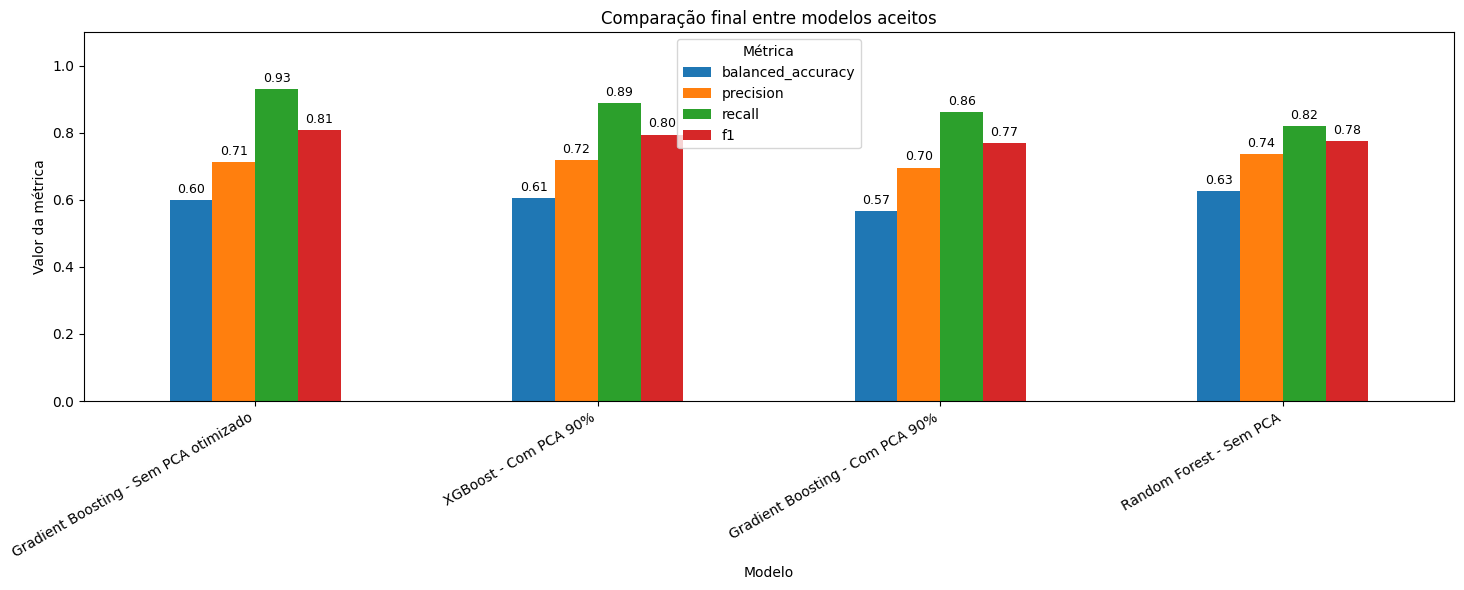

In [74]:
metricas_plot = ["balanced_accuracy", "precision", "recall", "f1"]

df_plot_final = df_modelos_aceitos.copy()

df_plot_final["modelo_versao"] = (
    df_plot_final["modelo"] + " - " + df_plot_final["versao"]
)

ax = df_plot_final.set_index("modelo_versao")[metricas_plot].plot(
    kind="bar",
    figsize=(15, 6)
)

plt.title("Comparação final entre modelos aceitos")
plt.ylabel("Valor da métrica")
plt.xlabel("Modelo")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.10)
plt.legend(title="Métrica")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

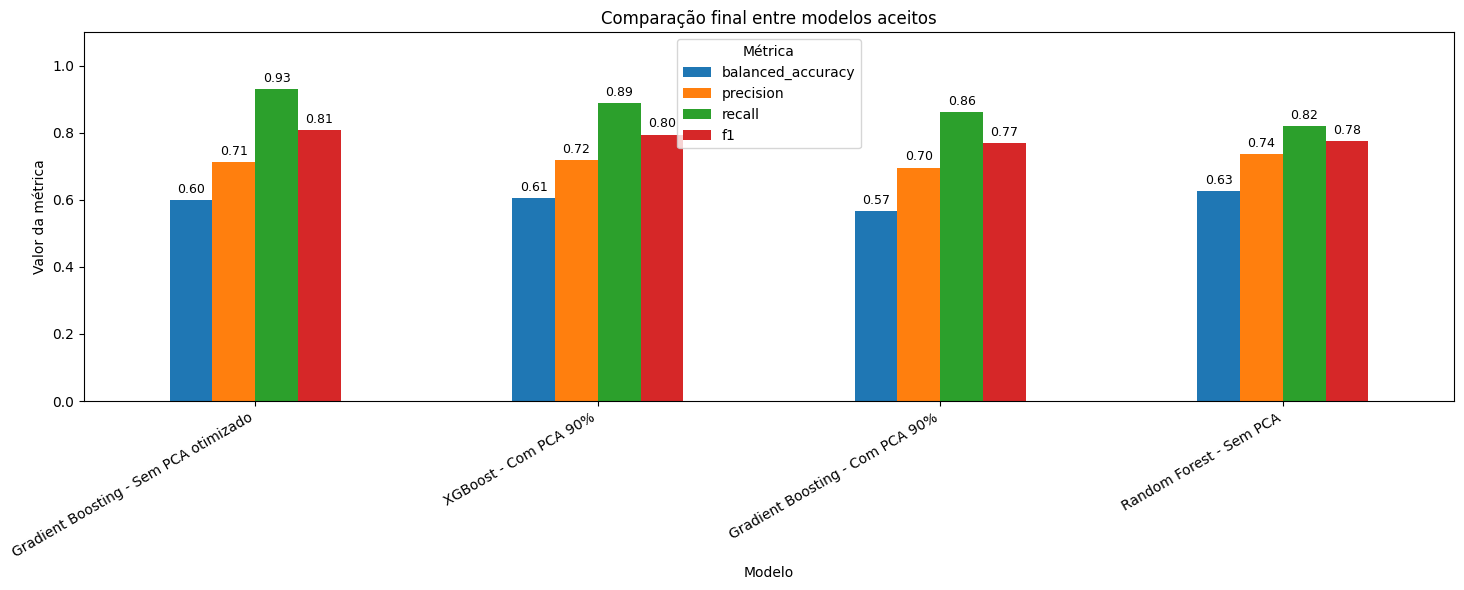

In [75]:
metricas_plot = ["balanced_accuracy", "precision", "recall", "f1"]

df_plot_final = df_modelos_aceitos.copy()

df_plot_final["modelo_versao"] = (
    df_plot_final["modelo"] + " - " + df_plot_final["versao"]
)

ax = df_plot_final.set_index("modelo_versao")[metricas_plot].plot(
    kind="bar",
    figsize=(15, 6)
)

plt.title("Comparação final entre modelos aceitos")
plt.ylabel("Valor da métrica")
plt.xlabel("Modelo")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.10)
plt.legend(title="Métrica")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "grafico_final_modelos_aceitos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()